In [25]:
import sys
sys.path.append('/Users/albertsmith/Documents/GitHub.nosync/')
import SLEEPY as sl
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ex0=sl.ExpSys(500,Nucs=['1H'])
ex0.set_inter('CS',i=0,Hz=100)
ex1=ex0.copy()
ex1.set_inter('CS',i=0,Hz=500)

1-spin system (1H)
B0 = 11.743 T (500.000 MHz 1H frequency)
rotor angle = 54.736 degrees
rotor frequency = 10.0 kHz
Temperature = 298 K
Powder Average: JCP59 with 99 angles
Interactions:
	CS on spin 0 with arguments: (Hz=500.00)


In [5]:
t_coal=1/(2*np.pi*(500-100))
L=sl.Liouvillian(ex0,ex1,kex=sl.Tools.twoSite_kex(tc=3*t_coal))

<AxesSubplot:>

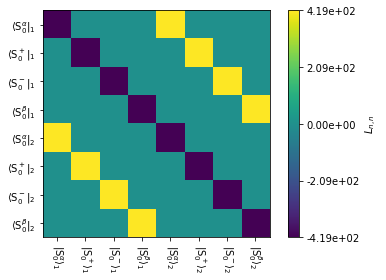

In [8]:
L.plot(mode='re')

In [9]:
Dt=1/(4*500)
U=L.U(Dt=Dt)

In [17]:
rho=sl.Rho('1Hx','1Hp')

In [18]:
rho.DetProp(U,n=100)

State-space reduction: 8->2


Density Matrix/Detection Operator
rho0: 1Hx
detect[0]: 1Hp
Current time is 50000.000 microseconds
100 time points have been recorded


<AxesSubplot:xlabel='$\\delta$($^{1}$H) / Hz', ylabel='I / a.u.'>

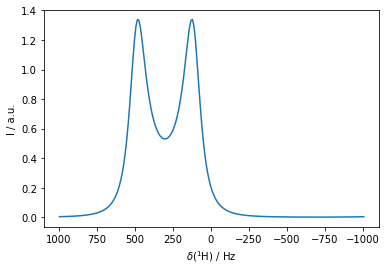

In [19]:
rho.plot(FT=True)

<AxesSubplot:xlabel='t / ms', ylabel='<$^{1}H^+$>'>

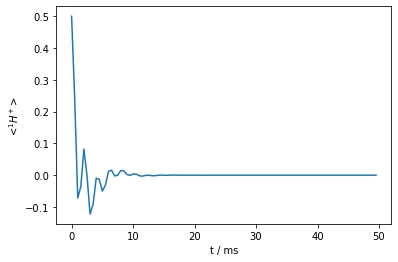

In [20]:
rho.plot()

In [22]:
U

Propagator with length of 500.000 microseconds (t0=0.000,tf=500.000)
Constructed from the following Liouvillian:
	Liouvillian under the following conditions:
		1-spin system (1H)
		B0 = 11.743 T (500.000 MHz 1H frequency)
		rotor angle = 54.736 degrees
		rotor frequency = 0 kHz
		Temperature = 298 K
		Powder Average: alpha0beta0 with 1 angle
	
	The individual Hamiltonians have the following interactions
		Hamiltonian #0
		Interactions:
			CS on spin 0 with arguments: (Hz=100.00)
		
		Hamiltonian #1
		Interactions:
			CS on spin 0 with arguments: (Hz=500.00)
		
		
	Hamiltonians are coupled by exchange matrix:
		array([[-418.87902048,  418.87902048],
		       [ 418.87902048, -418.87902048]])
	

<Axes3DSubplot:title={'center':'n=0'}, xlabel='kHz', ylabel='kHz'>

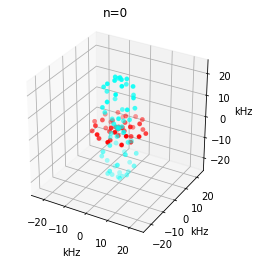

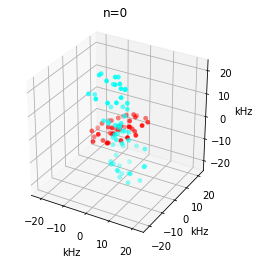

In [29]:
ex0=sl.ExpSys(500,Nucs=['15N','1H'],vr=60000)
ex0.set_inter('dipole',i0=0,i1=1,delta=sl.Tools.dipole_coupling(.102,'1H','15N'))
ex1=ex0.copy()
ex1.set_inter('dipole',i0=0,i1=1,delta=sl.Tools.dipole_coupling(.102,'1H','15N'),
             euler_d=[0,20,0])

L=sl.Liouvillian(ex0,ex1)
L.kex=sl.Tools.twoSite_kex(1e-5)


ex0.plot_inter(0,n=0)
ex1.plot_inter(0,n=0)

In [32]:
seq=L.Sequence()
_=seq.add_channel('15N',v1=30000)
U=seq.U()

In [35]:
rho=sl.Rho('15Nx','15Nx')
rho.DetProp(seq,n=6000)

State-space reduction: 32->16


Density Matrix/Detection Operator
rho0: 15Nx
detect[0]: 15Nx
Current time is 100000.000 microseconds
6000 time points have been recorded


<AxesSubplot:xlabel='t / ms', ylabel='<$^{15}N_x$>'>

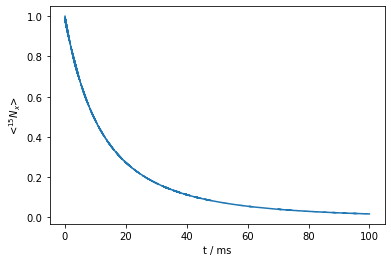

In [36]:
rho.plot()

In [37]:
ex0.list_interactions

CS, with args:
	i,ppm,Hz
CSA, with args:
	i,delta,deltaHz,eta,euler
J, with args:
	i0,i1,J
ZeroField, with args:
	i,D,E,euler
dipole, with args:
	i0,i1,D,delta,eta,euler
g, with args:
	i,gxx,gyy,gzz,euler
hyperfine, with args:
	i0,i1,Axx,Ayy,Azz,euler
quadrupole, with args:
	i,order,Cq,delta,DelPP,eta,euler


In [56]:
ex0=sl.ExpSys(500,Nucs=['13C','1H'],vr=60000)
ex0.set_inter('dipole',i0=0,i1=1,delta=sl.Tools.dipole_coupling(.109,'1H','13C'))
L=sl.Tools.Setup3siteSym(ex0,tc=1e-8)

array([<AxesSubplot:ylabel='$v_1$ / kHz'>,
       <AxesSubplot:xlabel='t / $\\mu$s', ylabel='$v_1$ / kHz'>],
      dtype=object)

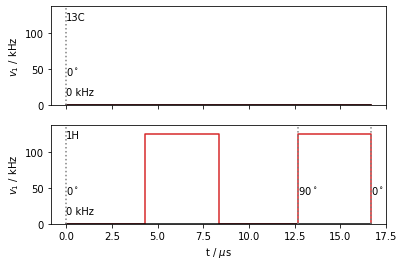

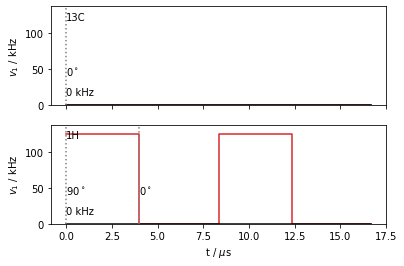

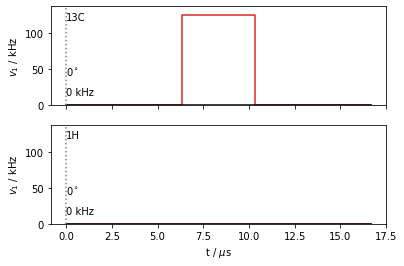

In [57]:
seqA=L.Sequence()
seqB=L.Sequence()
seqC=L.Sequence()
v1=125000
tpi=0.5/v1
dly=0.5*L.taur-tpi
seqA.add_channel('1H',t=[0,dly,dly+tpi,2*dly+tpi,L.taur],v1=[0,v1,0,v1],phase=[0,0,0,np.pi/2])
seqB.add_channel('1H',t=[0,tpi,tpi+dly,2*tpi+dly,L.taur],v1=[v1,0,v1,0],phase=[np.pi/2,0,0,0])
seqC.add_channel('13C',t=[0,L.taur/2-0.5*tpi,L.taur/2+0.5*tpi,L.taur],v1=[0,v1,0])
seqA.plot()
seqB.plot()
seqC.plot()

In [58]:
UA=seqA.U()
UB=seqB.U()
UC=seqC.U()

U1=L.Ueye()
U2=L.Ueye()

rho=sl.Rho('13Cx','13Cx')

for k in range(32):
    rho.reset()
    (U2*UC*U1*rho)()
    U1=UA*U1
    U2=UB*U2

<AxesSubplot:xlabel='t / ms', ylabel='<$^{13}C_x$>'>

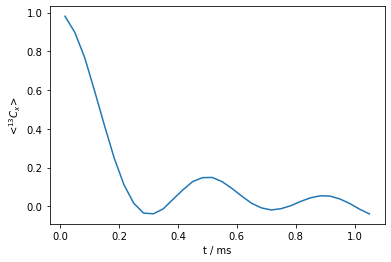

In [59]:
rho.plot()